In [66]:
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as scp
import PIL
import requests

from plotly.offline import init_notebook_mode, iplot

init_notebook_mode(connected=True)  

In [67]:
tips = sns.load_dataset('tips')

In [68]:
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

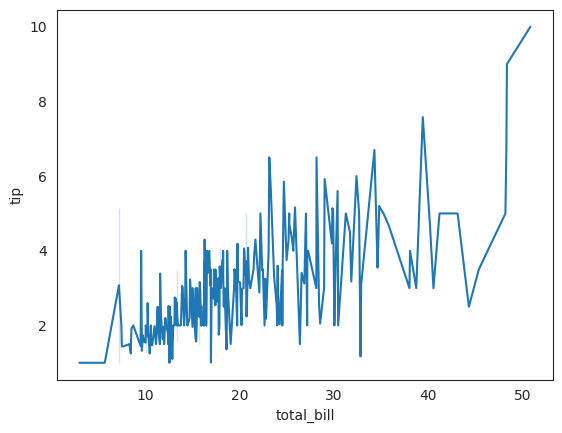

In [69]:
sns.lineplot(data=tips,x='total_bill',y='tip')
## transparent lines = multiple x for that y

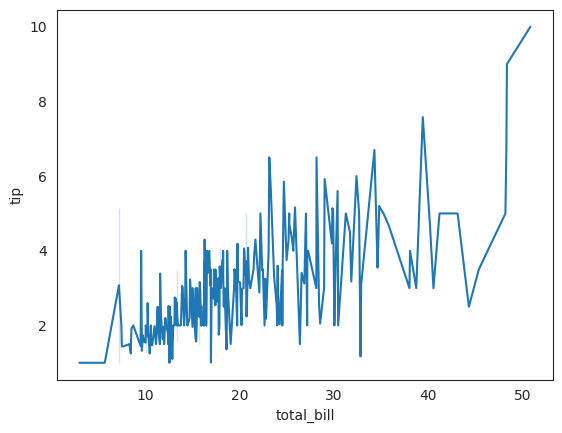

In [70]:
sns.lineplot(data=tips,x='total_bill',y='tip')
sns.set_style('darkgrid')

[Text(0.5, 1.0, 'tips vs bill'),
 Text(0.5, 0, 'bill total [$]'),
 Text(0, 0.5, 'tips [$]')]

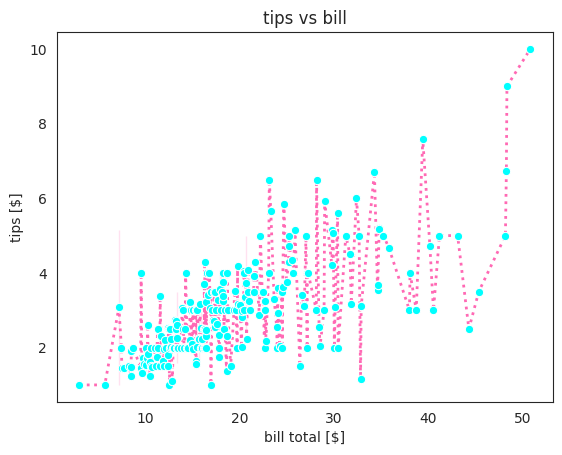

In [71]:
sns.set_style('white')

tipgraph = sns.lineplot(data=tips,x='total_bill',y='tip',
             linestyle=':',
             marker='o',
             color='hotpink',
             linewidth=2,
             markerfacecolor='cyan')
tipgraph.set(title='tips vs bill',
            xlabel='bill total [$]',
             ylabel = 'tips [$]')
## transparent lines = multiple x for that y

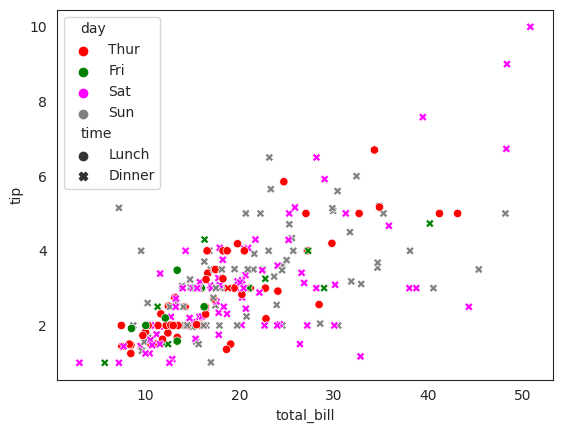

In [72]:
tipscatter = sns.scatterplot(data=tips,x='total_bill',y='tip',
                             style='time', ## set style by time column
                             hue='day', ## set colors as days column
                             palette=['red','green','magenta','grey']) ## select pallet

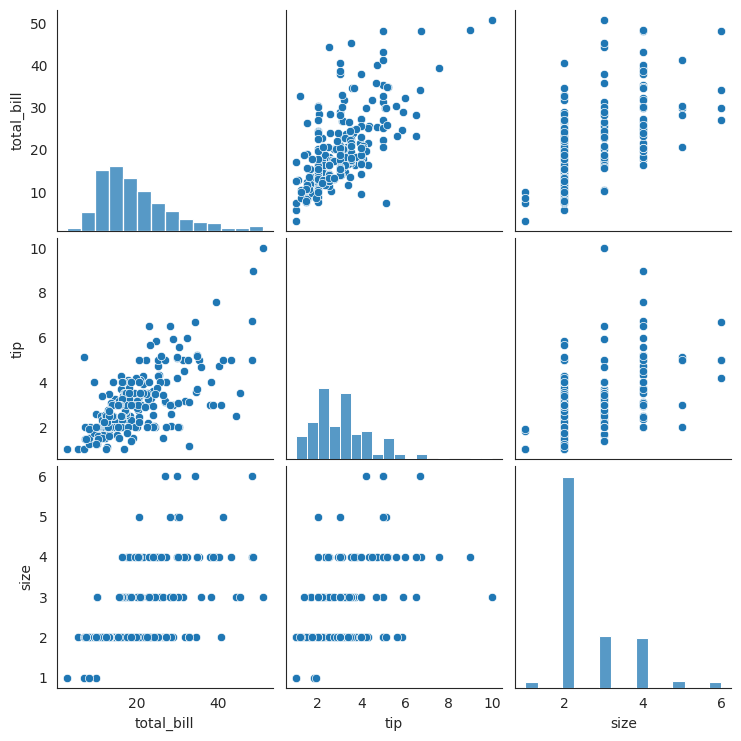

In [73]:
sns.pairplot(data=tips) ## gives plot of all pairs of all quantitative variables

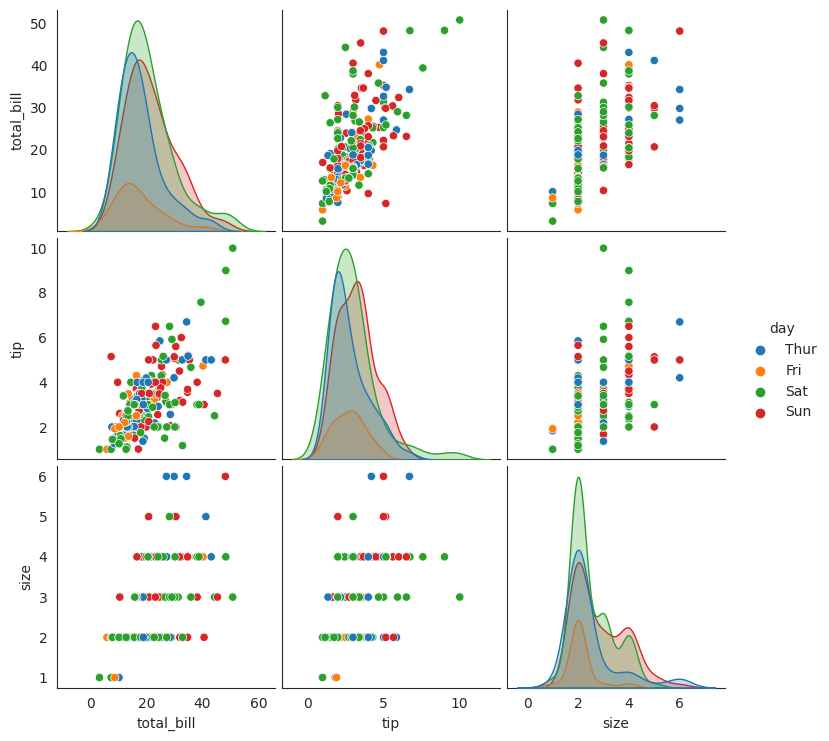

In [74]:
sns.pairplot(data=tips,
            hue='day') ## set colors as days column, use qualitative variable here

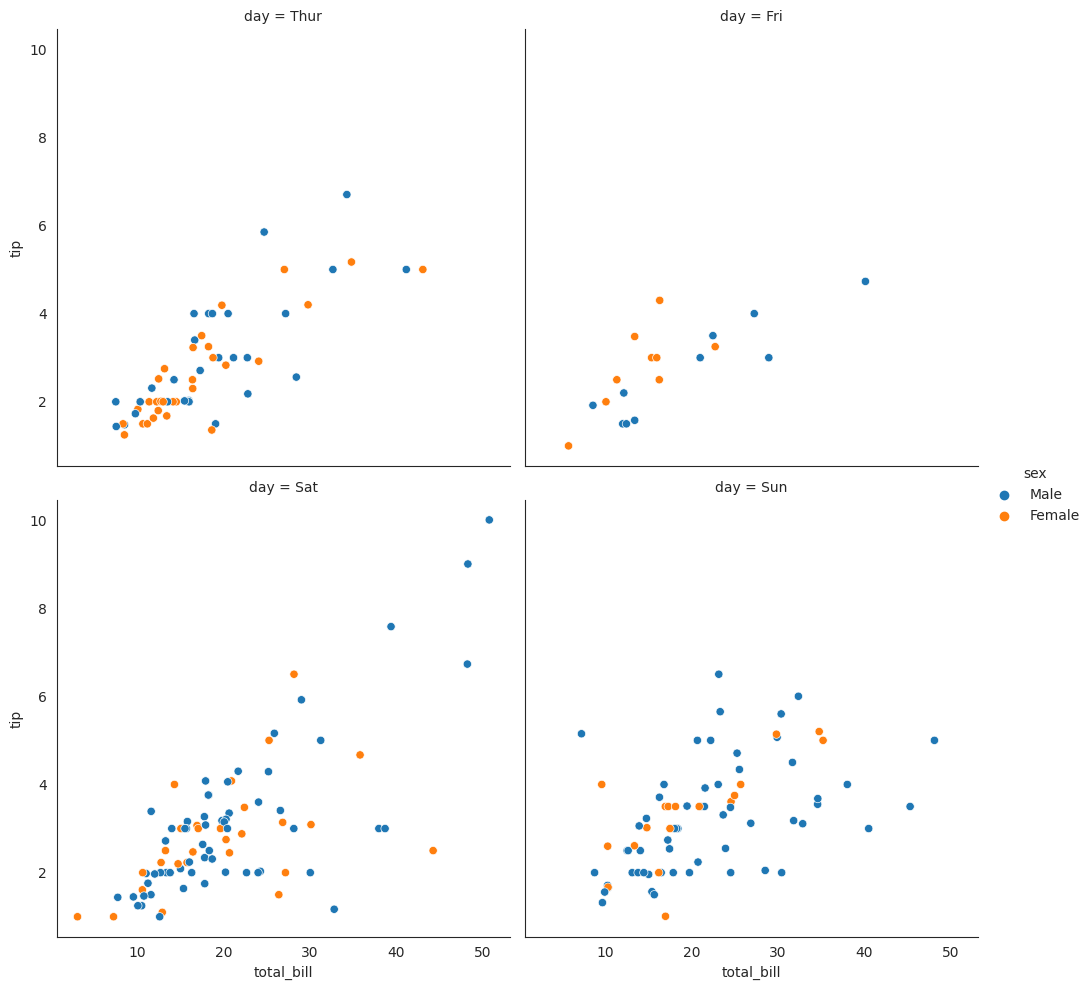

In [75]:
daysplot = sns.relplot(data=tips,x='total_bill',y='tip',hue='sex',
                       col='day', ## split plot into 4 panels by date
                       kind='scatter', ## type of plot
                       col_wrap=2) ## how many columns per row

In [76]:
import plotly.graph_objects as go
x1=np.array(["Luffy","Zoro","Nami","Usopp","Sanji"])
y1=np.array([110,180,240,99,220])


In [89]:
graph = go.Figure(layout=layout)
graph.add_trace(go.Bar(x=x1,y=y1))
graph.update_layout(title='Pirate scores',xaxis_title='Pirates',yaxis_title='Scores',width=500,height=500) ## is interactive
#graph.write_html('pirategraph.html') ## save interactive version

In [98]:
graph = go.Figure(layout=layout)
graph.add_trace(go.Scatter(x=x1,y=y1,
                           mode='markers', ## not connected points
                marker = dict(size=15,color='magenta',opacity=0.5, ## dict of marker features
                             line=dict(width=5,color='indigo') ## dict of features of line around markers
                             )))
graph.update_layout(title='Pirate scores',xaxis_title='Pirates',yaxis_title='Scores',
                    width=500,height=500) ## width and height in pixels
#graph.write_html('pirategraph.html') ## save interactive version

In [120]:
## wordclouds
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
print(df)
## df is whole dataset, quote is each column

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

In [121]:
text = " ".join(each for each in df.quote) # seperate by space, join all quotes

(-0.5, 399.5, 199.5, -0.5)

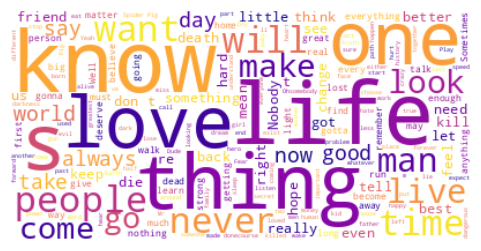

In [122]:
wordcloud = WordCloud(background_color='white',
                      colormap='plasma').generate(text) ## setup wordcloud image

fig,ax = plt.subplots(figsize=(7,3))
ax.imshow(wordcloud,    ## plot wordcloud using imshow
          interpolation='bilinear') ## interpolation smoothes visualization
ax.axis('off')

In [123]:
## ven diagrams:

In [124]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])


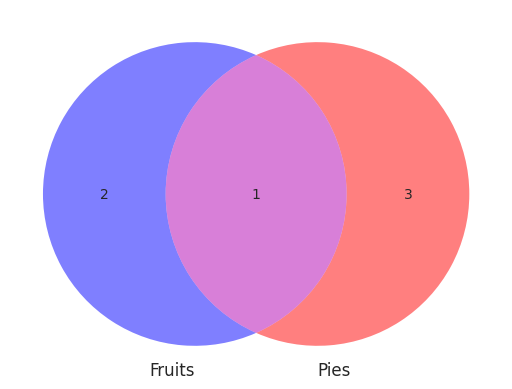

In [127]:
diagram = venn2_unweighted([A,B],
                            set_labels=('Fruits','Pies'), ## circle labels
                            set_colors=('blue','red'), ## circle colours
                            alpha=0.5) ## circle transparency

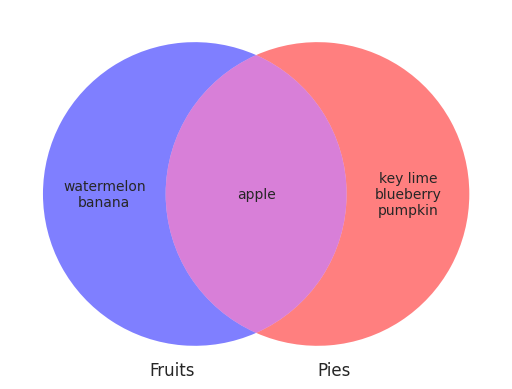

In [142]:
# 1 = in, 0 = out
# left and right perserved
#i.e., 10 is in left, out right
diagram = venn2_unweighted([A,B],
                            set_labels=('Fruits','Pies'), ## circle labels
                            set_colors=('blue','red'), ## circle colours
                            alpha=0.5) ## circle transparency

## \n makes new line
## - is for excluding, & is intersect
diagram.get_label_by_id("10").set_text('\n'.join(A - B))
diagram.get_label_by_id("11").set_text('\n'.join(A & B))
diagram.get_label_by_id("01").set_text('\n'.join(B - A))